## Resnet SSD model uning imagenet pretrained weights and training on agumented data

In [101]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

In [19]:
# custom functions
from src import data_managment
from src import general_testing_framework
from src.models import resnet_ssd_v0
from src.nn_tools import find_overfitting_piont
from src.tf_custom_callbacks import tf_early_stopping

In [99]:
import importlib
importlib.reload(resnet_ssd_v0)
importlib.reload(data_managment)
importlib.reload(general_testing_framework)

<module 'src.general_testing_framework' from 'e:\\Uni Projects\\COS 711\\Repo\\COS711_Assingment3\\notebooks\\src\\general_testing_framework.py'>

In [3]:
# global variables
from config import GLOBAL_CONFIG_RESULT_PATH, GLOBAL_CONFIG_DATA_PATH, GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH

In [100]:
# load data
augmented_images_path = f'{GLOBAL_CONFIG_DATA_PATH}/augmented_images/'
augmented_csv_path = f'{GLOBAL_CONFIG_DATA_PATH}/augmented_labels.csv'
expected_shape = (224, 224, 3) 

print("Loading data")
print(f"Images path: {augmented_images_path}")
print(f"Labels path: {augmented_csv_path}")

data_loader = data_managment.DataLoader(augmented_csv_path, augmented_images_path)
X, y = data_loader.load_data(alt_image_dir=GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, expected_image_shape=expected_shape, resize_images=True)
# X, y = data_loader.load_data(alt_image_dir=GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH, expected_image_shape=expected_shape, resize_images=False)

Loading data
Images path: ../../../Dataset//augmented_images/
Labels path: ../../../Dataset//augmented_labels.csv
Image aug_6_id_fzogq9kijh.jpg has an unexpected shape: Resized from (217, 217, 3) to (224, 224, 3)
Image aug_14_id_ylrsd2a6k4.jpg has an unexpected shape: Resized from (205, 205, 3) to (224, 224, 3)
Image aug_19_id_nzkpf8tr8o.jpg has an unexpected shape: Resized from (240, 240, 3) to (224, 224, 3)
Image aug_22_id_fvpi1edl84.jpg has an unexpected shape: Resized from (232, 232, 3) to (224, 224, 3)
Image aug_23_id_9cikz22vmm.jpg has an unexpected shape: Resized from (228, 228, 3) to (224, 224, 3)
Image aug_25_id_331urb6uko.jpg has an unexpected shape: Resized from (245, 245, 3) to (224, 224, 3)
Image aug_26_id_7fd9tfijwa.jpg has an unexpected shape: Resized from (239, 239, 3) to (224, 224, 3)
Image aug_27_id_e20xnaq5qn.jpg has an unexpected shape: Resized from (216, 216, 3) to (224, 224, 3)
Image aug_30_id_lpc9b0h4yl.jpg has an unexpected shape: Resized from (210, 210, 3) to (

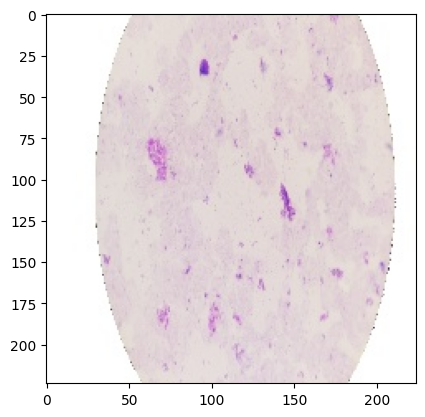

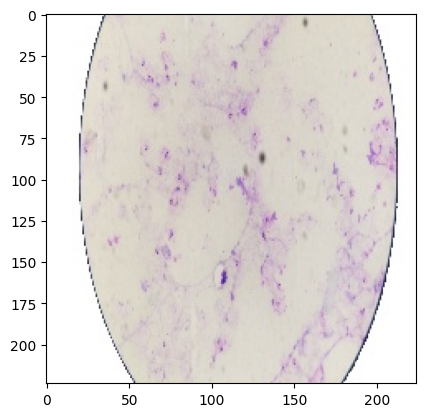

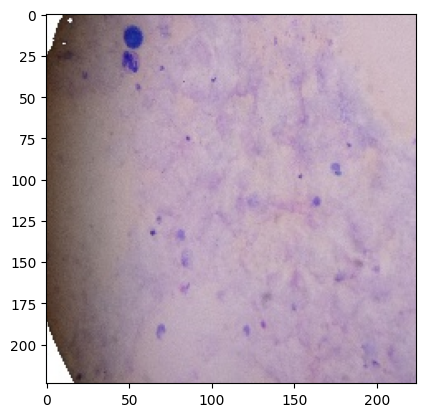

In [103]:
# display the first 5 images
for i in range(3):
    plt.imshow(X[i])
    plt.show()

In [32]:
data_loader.checkShapes(X, y)

X shape: (Number of images, Image Height, Image Width, Image Channels): (35756, 224, 224, 3)
y shape: (Number of images, 4 + Number of Classes): (35756, 7)


In [24]:
# create model
resnet_backbone = resnet_ssd_v0.resnet_backbone(input_shape=expected_shape, trainable=False, imagenet_weights=True)
resnet_ssd_model = resnet_ssd_v0.ssd_head(num_classes=3, input_shape=expected_shape, backbone=resnet_backbone)

# print output shape
resnet_ssd_output_shape = resnet_ssd_model.output_shape
print(f"Output shape: {resnet_ssd_output_shape}")

resnet_ssd_model.summary()

Using ResNet50 as a feature extractor with imagenet weights
Output shape: (None, 196, 7)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ssd_block1_conv     │ (None, 7, 7, 512) │  9,437,696 │ resnet50[0][0]    │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ssd_block1_bn       │ (None, 7, 7, 512) │      2,048 │ ssd_block1_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ssd_block1_relu     │ (None, 7, 7, 512) │          0 │ ssd_block1_bn[0]… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ssd_block2_conv     │ (None, 7, 7, 256) │  1,179,904 │ ssd_block1_relu[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ssd_block2_bn       │ (None, 7, 7, 256) │      1,024 │ ssd_block2_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ssd_block2_relu     │ (None, 7, 7, 256) │          0 │ ssd_block2_bn[0]… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loc_conv (Conv2D)   │ (None, 7, 7, 16)  │     36,880 │ ssd_block2_relu[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conf_conv (Conv2D)  │ (None, 7, 7, 12)  │     27,660 │ ssd_block2_relu[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loc_reshape         │ (None, 196, 4)    │          0 │ loc_conv[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conf_reshape        │ (None, 196, 3)    │          0 │ conf_conv[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ detection_output    │ (None, 196, 7)    │          0 │ loc_reshape[0][0… │
│ (Concatenate)       │                   │            │ conf_reshape[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,272,924 (130.74 MB)

 Trainable params: 10,683,676 (40.75 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [45]:
def convert_to_numpy(data): 
    if isinstance(data, pd.DataFrame): 
        return data.to_numpy().astype(np.float32) 
    else: 
        raise ValueError("Input data is not a pandas DataFrame")

In [51]:
print(y.shape)
if 1 in y.iloc[:, 0].values:
    print("Found column 0")
else:
    print("Column 0 not found")
y.head()

# get row 0
# y.iloc[0]

y_target = convert_to_numpy(y)



(35756, 7)
Found column 0


In [57]:
# create training framework
framework = general_testing_framework.ModelTrainingFrameworkBasic(resnet_ssd_model, X, y_target, batch_size=32, epochs=1, test_size=0.2)

# train model
framework.train(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

894/894 ━━━━━━━━━━━━━━━━━━━━ 558s 618ms/step - accuracy: 0.2728 - loss: 35086.0156 - val_accuracy: 0.2988 - val_loss: 135867.1719


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=../results//resnet_ssd_v0.

In [58]:
# save model using tensorflow saved model format
model_path = f"{GLOBAL_CONFIG_RESULT_PATH}/resnet_ssd_v0.keras"
framework.save_model(model_path)

Minimal Resnet SSD Model

In [67]:
# create model using custom backbone
# min_resnet_backbone = resnet_ssd_v0.custom_resnet_backbone(input_shape=expected_shape, num_blocks=3, initial_filters=32, growth_rate=2, trainable=True)
# min_resnet_ssd_model = resnet_ssd_v0.ssd_head(num_classes=3, input_shape=expected_shape, backbone=min_resnet_backbone)
min_resnet_ssd_model = resnet_ssd_v0.ssd_with_min_resnet_backbone(
    num_classes=3, 
    input_shape=expected_shape, 
    num_res_blocks=3, 
    initial_filters=32, 
    growth_rate=2, 
    num_ssd_blocks=2, 
    shrink_rate=2)

# print output shape
print(f"Output shape: {min_resnet_ssd_model.output_shape}")

min_resnet_ssd_model.summary()

Output shape: (None, 3136, 7)


Model: "ssd_with_custom_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 112, 112,  │        896 │ input_layer_8[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 112, 112,  │        128 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_relu (ReLU) │ (None, 112, 112,  │          0 │ initial_bn[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 112, 112,  │      9,248 │ initial_relu[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 112, 112,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1 (ReLU) │ (None, 112, 112,  │          0 │ block1_bn1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 112, 112,  │      9,248 │ block1_relu1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 112, 112,  │        128 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 112, 112,  │          0 │ block1_bn2[0][0], │
│                     │ 32)               │            │ initial_relu[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out (ReLU)   │ (None, 112, 112,  │          0 │ block1_add[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 56, 56,    │     18,496 │ block1_out[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn1          │ (None, 56, 56,    │        256 │ block2_conv1[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu1 (ReLU) │ (None, 56, 56,    │          0 │ block2_bn1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 56, 56,    │     36,928 │ block2_relu1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_shortcut     │ (None, 56, 56,    │      2,112 │ block1_out[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_bn2          │ (None, 56, 56,    │        256 │ block2_conv2[0][

 Total params: 933,404 (3.56 MB)

 Trainable params: 931,292 (3.55 MB)

 Non-trainable params: 2,112 (8.25 KB)

In [111]:
# create training framework
framework_min = general_testing_framework.ModelTrainingFrameworkBasic(min_resnet_ssd_model, X, y_target, batch_size=32, epochs=5, test_size=0.2)

# train model
framework_min.train(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Epoch 1/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 357s 394ms/step - accuracy: 0.6833 - loss: 24829.2422 - val_accuracy: 0.5887 - val_loss: 129101.4844
Epoch 2/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 347s 388ms/step - accuracy: 0.6855 - loss: 25304.4453 - val_accuracy: 0.5651 - val_loss: 130259.0547
Epoch 3/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 343s 383ms/step - accuracy: 0.6918 - loss: 25388.2598 - val_accuracy: 0.5944 - val_loss: 136061.4531
Epoch 4/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 340s 380ms/step - accuracy: 0.6894 - loss: 24396.7012 - val_accuracy: 0.5867 - val_loss: 132661.5938
Epoch 5/5
894/894 ━━━━━━━━━━━━━━━━━━━━ 341s 381ms/step - accuracy: 0.6890 - loss: 24888.3828 - val_accuracy: 0.5745 - val_loss: 134717.3750


In [112]:
# save model using tensorflow saved model format
model_path_min = f"{GLOBAL_CONFIG_RESULT_PATH}/resnet_ssd_v0_min_2.keras"
framework_min.save_model(model_path_min)

Plotting history and overfitting...
Overfitting epoch: 48


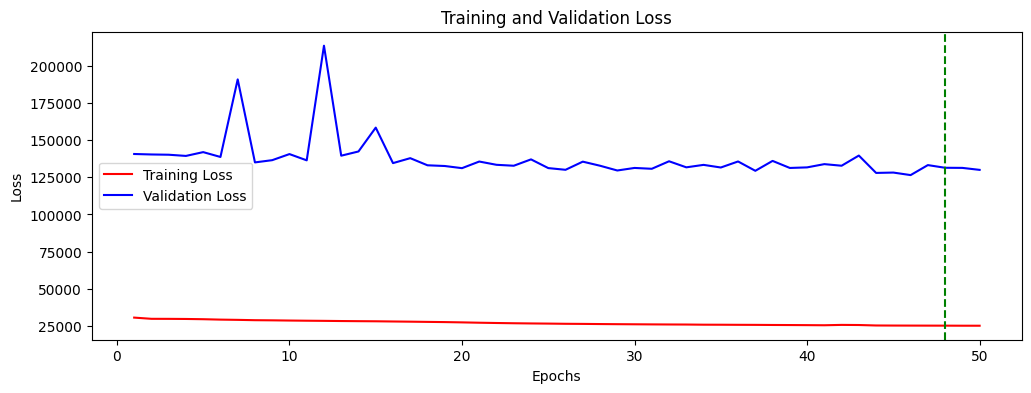

In [71]:
history = framework_min.history

from src.nn_tools import plot_history_and_overfitting

plot_history_and_overfitting(history.history, threshold=0.1, epochs_threshold=10)

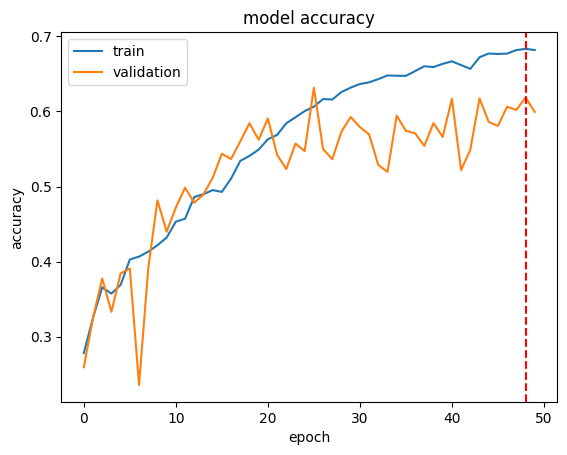

In [75]:
# plot accuracy

overfit_piont = find_overfitting_piont(history.history, threshold=0.01, epochs_threshold=30)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.axvline(x=overfit_piont, color='r', linestyle='--')
plt.show()

In [88]:
import cv2

# Function to plot an image with its bounding boxes
def plot_image_with_boxes(image, boxes, YOLO_FORMAT=False):
    # Get image dimensions
    h, w, _ = image.shape

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Plot each bounding box
    for box in boxes:
        if YOLO_FORMAT:
            class_id, x_center, y_center, width, height = box
            xmin = int((x_center - width / 2) * w)
            ymin = int((y_center - height / 2) * h)
            xmax = int((x_center + width / 2) * w)
            ymax = int((y_center + height / 2) * h)
        else:
            xmin, ymin, xmax, ymax, class_id = box

        # Draw the bounding box
        plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                          edgecolor='red', facecolor='none', linewidth=2))
        # plt.text(xmin, ymin - 10, f'Class {int(class_id)}', color='red', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()

In [ ]:
#merge overlapping bounding boxes using NMS (keeps most confident)

def iou(box1, box2):
    x1, y1, w1, h1, class_id1 = box1
    x2, y2, w2, h2, class_id2 = box2
    
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1+w1, x2+w2)
    yi2 = min(y1+h1, y2+h2)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    iou = inter_area / (box1_area + box2_area - inter_area)
    
    return iou

def NMS(boxes, scores, iou_threshold):
    indices = np.argsort(scores)[::-1]
    keep = []
    
    while len(indices) > 0:
        idx = indices[0]
        keep.append(idx)
        indices = indices[1:]
        
        filtered = []
        for i in indices:
            if iou(boxes[idx], boxes[i]) < iou_threshold:
                filtered.append(i)
                
        indices = np.array(filtered)
        
    return keep

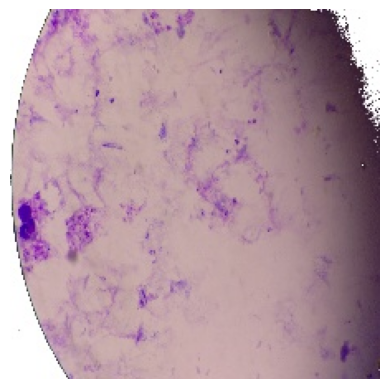

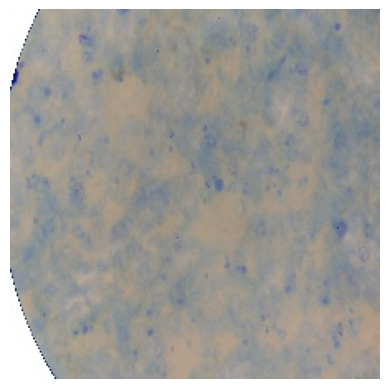

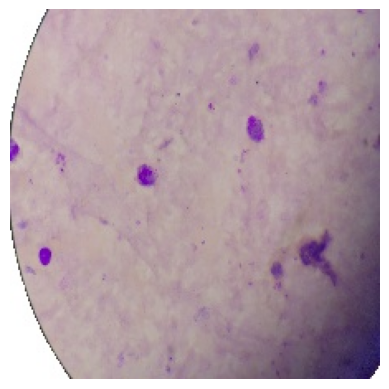

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step
[[[4.46300697e+01 5.83529587e+01 4.64137344e+01 ... 1.46256294e-04
   5.01915347e-03 2.76190555e-03]
  [4.29093132e+01 5.64196014e+01 4.48222122e+01 ... 1.39799580e-04
   4.75523714e-03 2.66150222e-03]
  [4.42030792e+01 5.79735489e+01 4.57939034e+01 ... 1.40904784e-04
   4.88205673e-03 2.72361608e-03]
  ...
  [1.01741686e+01 8.44125462e+00 1.07302847e+01 ... 1.35667506e-04
   2.67619430e-03 1.28270814e-03]
  [1.04555893e+01 8.90772724e+00 1.10350733e+01 ... 1.43058496e-04
   2.79345759e-03 1.32710556e-03]
  [4.05072021e+01 2.81442661e+01 4.25493355e+01 ... 3.64400119e-01
   3.68355095e-01 2.54623801e-01]]

 [[4.90081291e+01 6.12089500e+01 5.05547104e+01 ... 3.75319301e-04
   7.30096409e-03 3.97007307e-03]
  [4.72719765e+01 5.91546173e+01 4.89191818e+01 ... 3.71603179e-04
   6.98144455e-03 3.74813145e-03]
  [4.82877045e+01 6.03565407e+01 4.98670845e+01 ... 3.81075777e-04
   7.11953500e-03 3.89604061e-03]
  ...
  [3.93158722e+00 7.45894432e-01 3.95

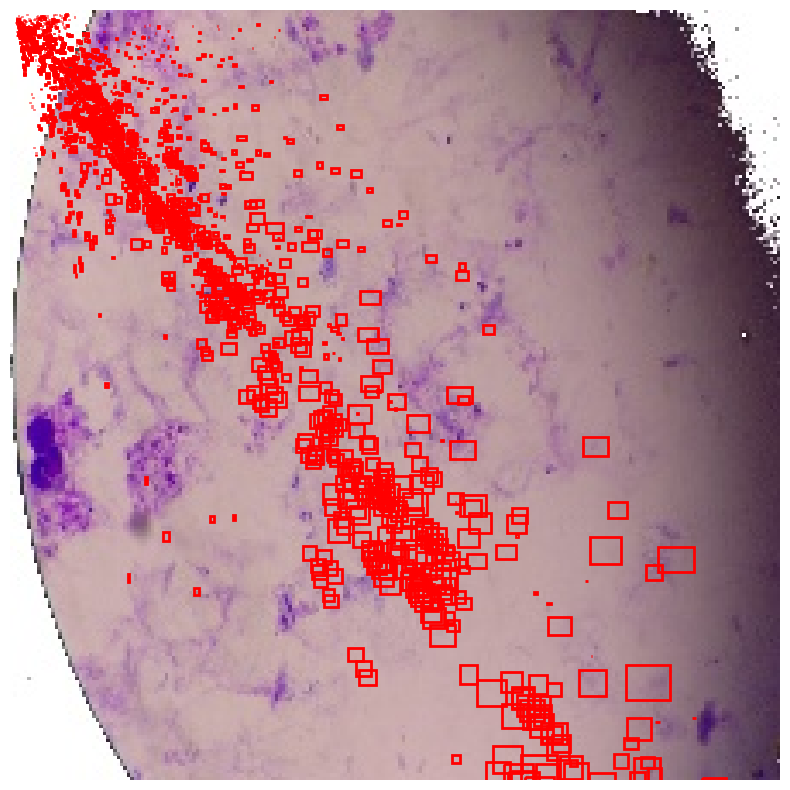

[[49.00812912 61.20895004 50.55471039 62.56726074  1.        ]
 [47.27197647 59.15461731 48.91918182 60.41765213  1.        ]
 [48.28770447 60.35654068 49.8670845  61.82201385  1.        ]
 ...
 [ 3.93158722  0.74589443  3.95450664  0.78180093  1.        ]
 [ 4.03591681  0.75291979  4.03329611  0.81591767  1.        ]
 [17.83602715  3.33487654 18.08706284  3.5045948   0.        ]]


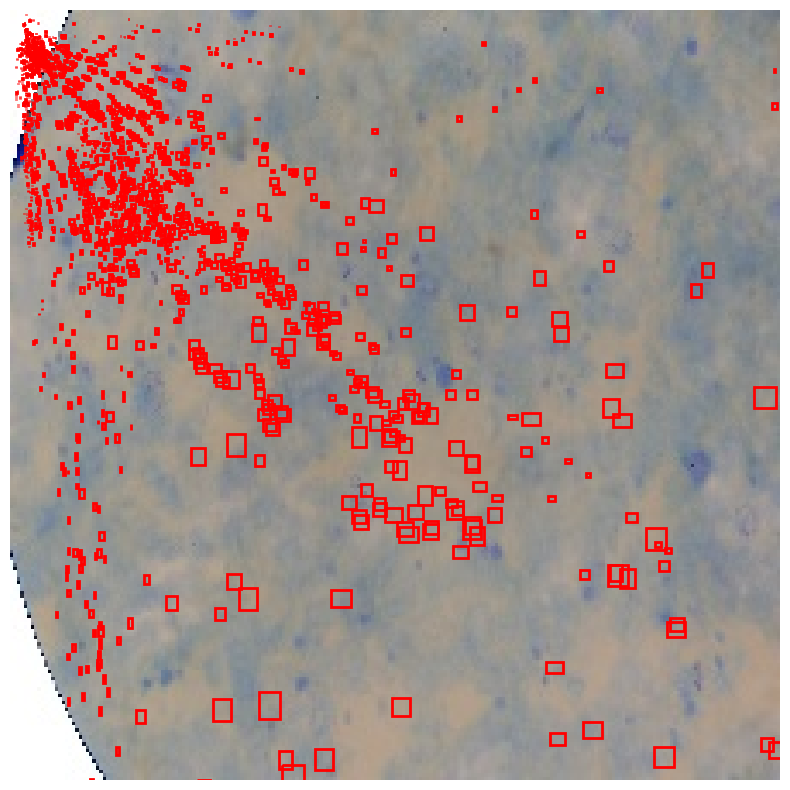

[[22.8879776   4.4874301  23.57103729  4.80938387  1.        ]
 [22.19486046  4.34161806 22.88257599  4.63319874  1.        ]
 [22.45438385  4.60090637 23.22761917  4.79783773  1.        ]
 ...
 [ 1.27929568  1.34303403  1.31288874  1.36520815  1.        ]
 [ 1.34091628  1.46241188  1.40550339  1.43179965  1.        ]
 [ 6.86218834  7.59721994  6.93489552  7.63155651  0.        ]]


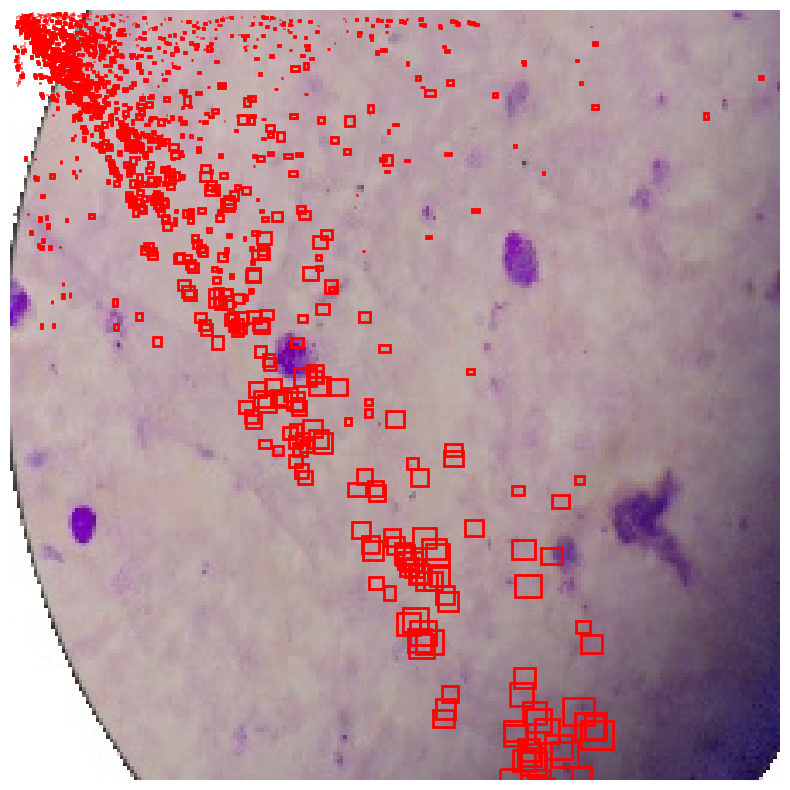

In [89]:
# draw bounding boxes using the model
# use the first 3 images

expected_image_shape = (224, 224, 3)

# test csv path
test_csv_path = f'{GLOBAL_CONFIG_DATA_PATH}/test.csv'
image_dir = GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH
alt_image_dir = f'{GLOBAL_CONFIG_DATA_PATH}/images/'

data = pd.read_csv(test_csv_path)

# split x (load the images from id) and y (the class and bounding box)
X_names = data['Image_ID']

# load the images
count = 0
test_pred_images = []
for name in X_names:
    image = None
    try:
        image = plt.imread(f"{image_dir}/{name}")

    except FileNotFoundError:
        if alt_image_dir:
            image = plt.imread(f"{alt_image_dir}/{name}")

        else:
            print(f"Image {name} not found in {image_dir} or {alt_image_dir}")
            continue
    
    # print(f"Loaded image {name} with shape {image.shape}")

    if expected_image_shape: # check if the image has the expected shape
        if image.shape != expected_image_shape:
            print(f"Image {name} has an unexpected shape:", end=' ')
            old_shape = image.shape
            image = tf.image.resize(image, expected_image_shape[:2])
            print(f"Resized from {old_shape} to {image.shape}")

    test_pred_images.append(image)

    if count == 3:
        break

test_pred_images = np.array(test_pred_images)

# display the images
for i in range(3):
    plt.imshow(test_pred_images[i])
    plt.axis('off')
    plt.show()

# # predict the bounding boxes
test_y_pred = min_resnet_ssd_model.predict(test_pred_images)

print(test_y_pred)

# convert to bounding boxes
final_test_boxes = []
final_test_boxes_iou_format = []
for i in range(3):
    # first 4 is ('ymin', 'xmin', 'ymax', 'xmax') and rest is class probabilities
    boxes = test_y_pred[i]

    box_coords = boxes[:, :4]
    class_probs = boxes[:, 4:]

    # softmax for class predictions
    class_preds = np.argmax(class_probs, axis=1)

    # combine box_coords and class_preds --> (xmin, ymin, xmax, ymax, class_id)
    boxes = np.concatenate([box_coords, class_preds[:, np.newaxis]], axis=1)
    print(boxes)

    # draw bounding boxes
    plot_image_with_boxes(test_pred_images[i], boxes, YOLO_FORMAT=False)


[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


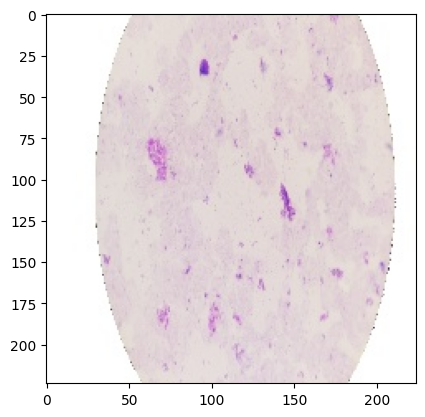

In [116]:
# display the images of X
image = X[0]
print(image)

# display the image
plt.imshow(image)
plt.show()

In [107]:
# validate the model on whole dataset

def validate_model(model, X, y):
    # convert y to numpy
    y_target = convert_to_numpy(y)

    output_boundig_size = model.output_shape[1]

    new_Y_data = np.zeros((y_target.shape[0], output_boundig_size, y_target.shape[1]))

    for i in range(y_target.shape[0]):
        new_Y_data[i] = np.tile(y_target[i], (output_boundig_size, 1))

    print(new_Y_data.shape)
    
    y_target = new_Y_data

    # get the predictions
    y_pred = model.predict(X)

    accuracy = tf.keras.metrics.Accuracy()

    # calculate the accuracy
    accuracy.update_state(y_target, y_pred)

    return accuracy.result().numpy()

In [113]:
# validate the model
accuracy = validate_model(min_resnet_ssd_model, X, y)

(35756, 3136, 7)
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 103s 91ms/step


In [117]:
# desplay the accuracy as a percentage
print(f"Model accuracy: {accuracy * 100}%")

Model accuracy: 0.013603115803562105%
